In [26]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [27]:
mfdata_DIR='/home/arif/Desktop/Python Lab/Assingment/GPM_Data/gpm*'
df=xr.open_mfdataset(mfdata_DIR,parallel=True, engine='netcdf4')


In [28]:
df

<xarray.Dataset> Size: 2MB
Dimensions:        (time: 48, lon: 85, lat: 106)
Coordinates:
  * lat            (lat) float32 424B 18.05 18.15 18.25 ... 28.35 28.45 28.55
  * lon            (lon) float32 340B 83.95 84.05 84.15 ... 92.15 92.25 92.35
  * time           (time) object 384B 2019-05-25 00:00:00 ... 2019-05-25 23:3...
Data variables:
    precipitation  (time, lon, lat) float32 2MB dask.array<chunksize=(1, 85, 106), meta=np.ndarray>
Attributes:
    FileHeader:                      DOI=10.5067/GPM/IMERG/3B-HH/07;\nDOIauth...
    FileInfo:                        DataFormatVersion=7e;\nTKCodeBuildVersio...
    history:                         2026-04-11 10:11:18 GMT hyrax-1.17.1 htt...
    history_json:                    [{"$schema":"https:\/\/harmony.earthdata...
    Grid.GridHeader:                 BinMethod=ARITHMETIC_MEAN;\nRegistration...
    Grid.fullnamepath:               /Grid
    DODS_EXTRA.Unlimited_Dimension:  time

In [29]:
min_lon=88.27
min_lat=22.45
max_lon=88.46
max_lat=22.68

In [30]:
df1=df.sel(lat=slice(min_lat,max_lat),lon=slice(min_lon,max_lon))

In [31]:
df1

<xarray.Dataset> Size: 1kB
Dimensions:        (time: 48, lon: 2, lat: 2)
Coordinates:
  * lat            (lat) float32 8B 22.55 22.65
  * lon            (lon) float32 8B 88.35 88.45
  * time           (time) object 384B 2019-05-25 00:00:00 ... 2019-05-25 23:3...
Data variables:
    precipitation  (time, lon, lat) float32 768B dask.array<chunksize=(1, 2, 2), meta=np.ndarray>
Attributes:
    FileHeader:                      DOI=10.5067/GPM/IMERG/3B-HH/07;\nDOIauth...
    FileInfo:                        DataFormatVersion=7e;\nTKCodeBuildVersio...
    history:                         2026-04-11 10:11:18 GMT hyrax-1.17.1 htt...
    history_json:                    [{"$schema":"https:\/\/harmony.earthdata...
    Grid.GridHeader:                 BinMethod=ARITHMETIC_MEAN;\nRegistration...
    Grid.fullnamepath:               /Grid
    DODS_EXTRA.Unlimited_Dimension:  time

In [32]:
pricp=df1.precipitation

In [33]:
pricp_avg=pricp.mean(dim=['lat','lon'])

In [34]:
pricp_avg.size

48

In [35]:
pricp_avg1=[]
for i in range(0,47):
    pricp_avg1.append(pricp_avg[i]+pricp_avg[i+1])

In [36]:
pricp_avg1=np.asarray(pricp_avg1)

In [37]:
pricp_avg1.size

47

In [38]:
time=np.arange(0,47)
time.shape
print(time)


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46]


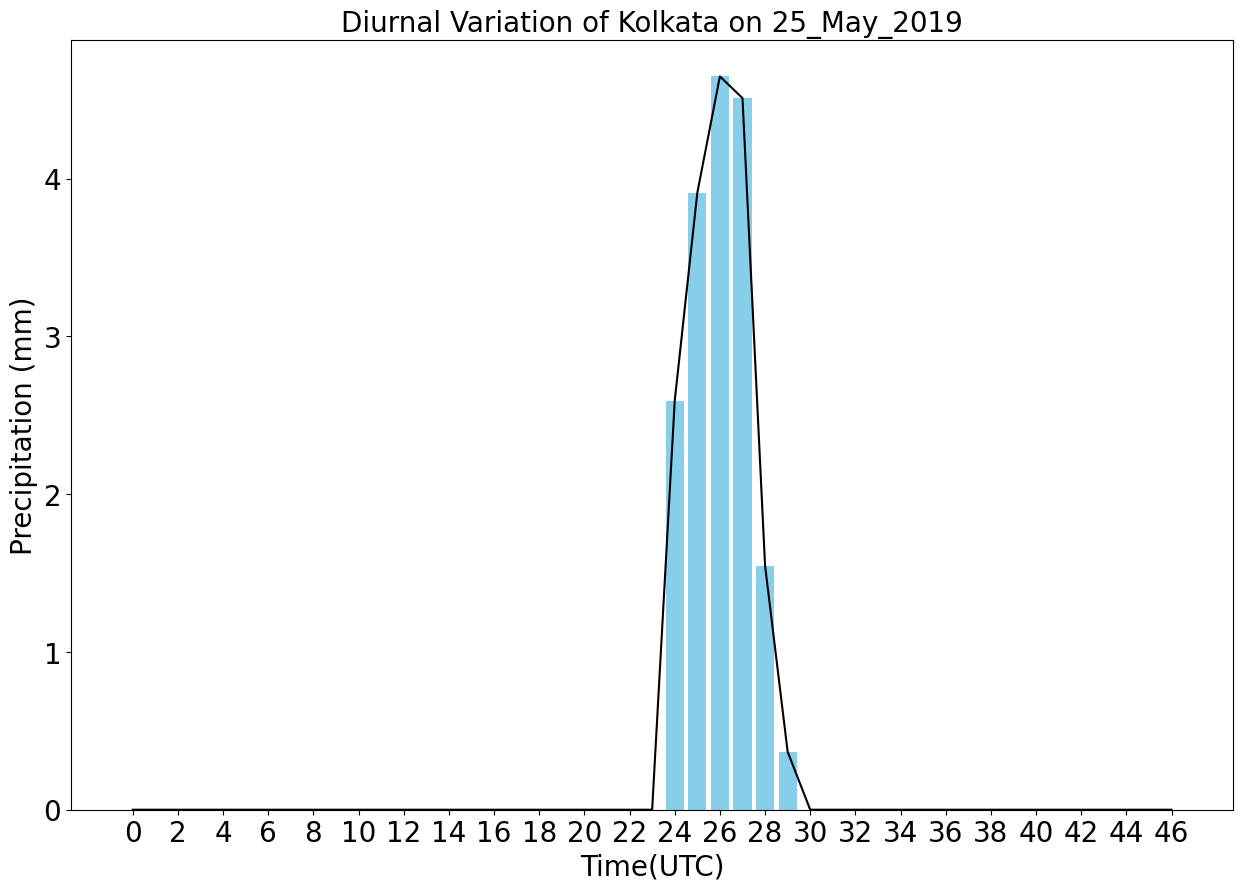

In [39]:
plt.figure(figsize=(15,10))
plt.bar(time,pricp_avg1,color="skyblue")
plt.plot(time,pricp_avg1,color="black")
plt.xticks(np.arange(0,48,step=2),fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Time(UTC)',fontsize=20)
plt.ylabel('Precipitation (mm)',fontsize=20)
plt.title("Diurnal Variation of Kolkata on 25_May_2019",fontsize=20)
plt.savefig('/home/arif/Desktop/Python Lab/Assingment/Diurnal Variation of Kolkata on 25_May_2019.jpg',dpi=300)

